# `show_2d` — Visualisation Tutorial

This notebook demonstrates **all** the ways to use `show_2d` and the
`ShowParams` helper classes for normalization and scale bars.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import quantem as em
from quantem.core.visualization import show_2d, ShowParams

/home/amccray/code/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# --- Load real data ---
cameraman = np.load("../../data/cameraman.npy")

ducky_ds = em.io.load("../../data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dp = ducky_ds.dp_mean  # mean diffraction pattern
real_sampling = ducky_ds.sampling[0]  # real-space Å/px
recip_sampling = ducky_ds.sampling[2]  # reciprocal-space 1/Å per px

print(f"cameraman  : {cameraman.shape}")
print(f"ducky 4D   : {ducky_ds.shape}, sampling={ducky_ds.sampling}")
print(f"mean DP    : {dp.shape}")

cameraman  : (512, 512)
ducky 4D   : (37, 37, 200, 200), sampling=[4.    4.    0.025 0.025]
mean DP    : (200, 200)


## 1. Basic Usage

A single 2D array, a row (list), or a grid (nested list).

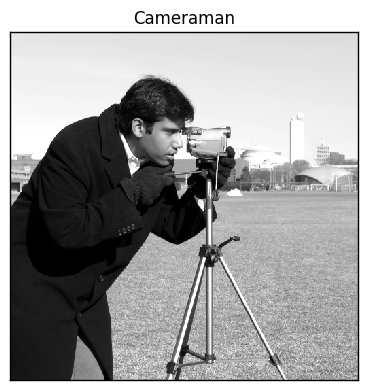

In [3]:
# Single image
show_2d(cameraman, title="Cameraman");

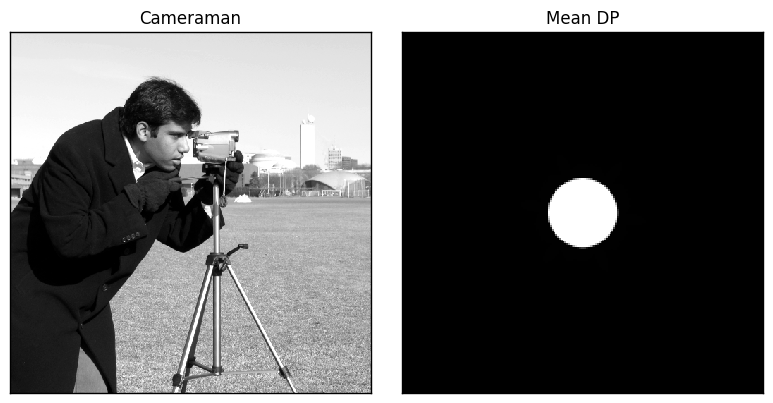

In [4]:
# Row of images
show_2d([cameraman, dp], title=["Cameraman", "Mean DP"]);

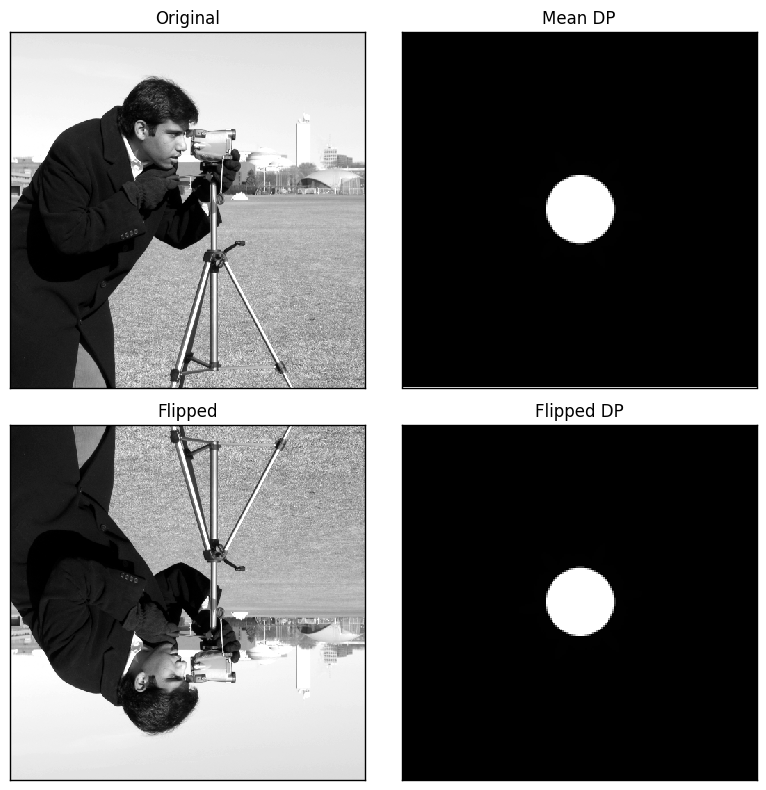

In [5]:
# 2×2 grid
show_2d(
    [[cameraman, dp], [cameraman[::-1], dp[::-1]]],
    title=[["Original", "Mean DP"], ["Flipped", "Flipped DP"]],
);

## 2. Normalization with `ShowParams.Norm`

`ShowParams.Norm` is a tab-completable dataclass that controls how pixel
values are mapped to the display range. It has two knobs:

| Concept | Options | What it does |
|---------|---------|-------------|
| **Interval** (`interval_type`) | `"quantile"`, `"manual"`, `"centered"` | *Which* data values map to 0 and 1 |
| **Stretch** (`stretch_type`) | `"linear"`, `"power"`, `"logarithmic"`, `"asinh"` | *How* the mapping is shaped |

Preset classmethods combine the two for common cases.

### 2a. Interval types

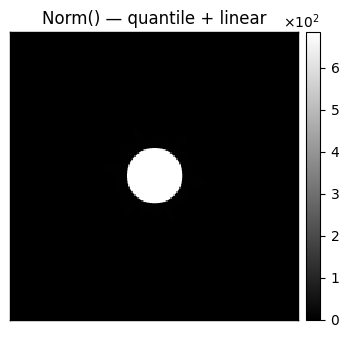

In [6]:
# Default: quantile + linear (clips outliers at 2% / 98%)
show_2d(dp, norm=ShowParams.Norm(), title="Norm() — quantile + linear", cbar=True);

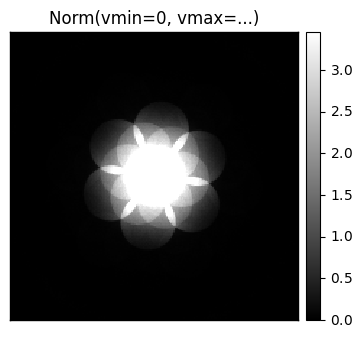

In [32]:
# Manual interval — set vmin/vmax (interval_type is auto-inferred)
show_2d(
    dp,
    norm=ShowParams.Norm(vmin=0, vmax=dp.max() * 0.005),
    title="Norm(vmin=0, vmax=...)",
    cbar=True,
);

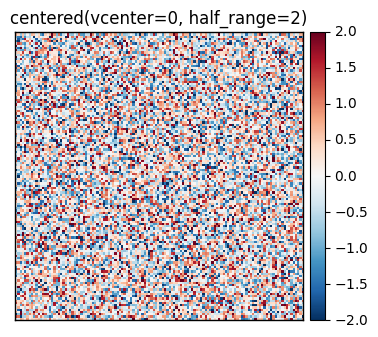

In [8]:
# Centered interval — symmetric around vcenter (great for ± data)
centered_data = np.random.RandomState(0).randn(128, 128)
show_2d(
    centered_data,
    norm=ShowParams.Norm.centered(vcenter=0, half_range=2),
    title="centered(vcenter=0, half_range=2)",
    cmap="RdBu_r",
    cbar=True,
);

### 2b. Stretch types

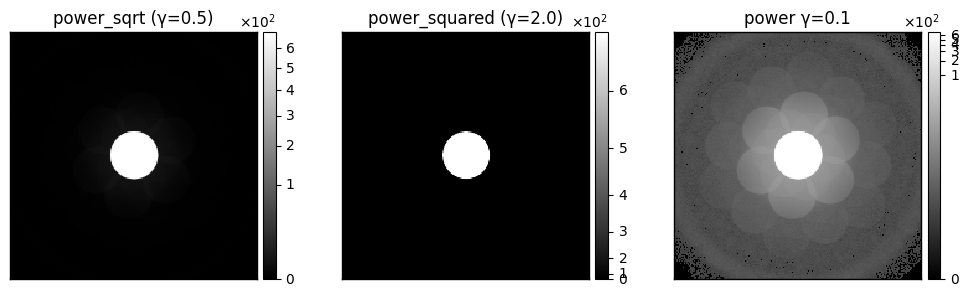

In [36]:
# Power stretch: sqrt (0.5) vs squared (2.0)
show_2d(
    [dp, dp, dp],
    norm=[
        ShowParams.Norm.power_sqrt(),
        ShowParams.Norm.power_squared(),
        ShowParams.Norm(power=0.1),
    ],
    title=["power_sqrt (γ=0.5)", "power_squared (γ=2.0)", "power γ=0.1"],
    cbar=True,
);

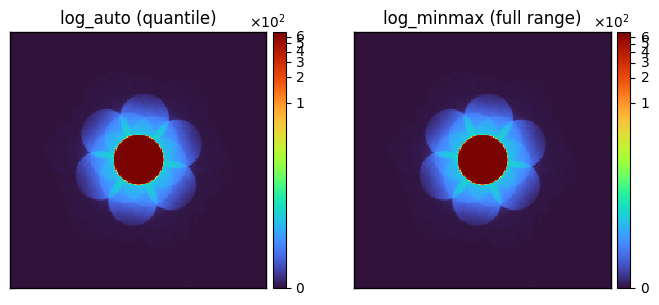

In [37]:
# Log stretch — ideal for diffraction data with high dynamic range
show_2d(
    [dp, dp],
    norm=[ShowParams.Norm.log_auto(), ShowParams.Norm.log_minmax()],
    title=["log_auto (quantile)", "log_minmax (full range)"],
    cmap="turbo",
    cbar=True,
);

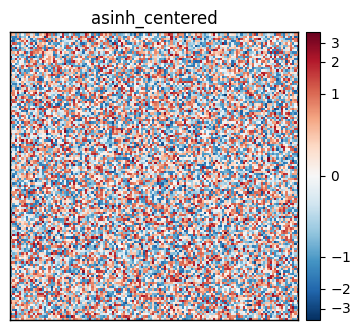

In [11]:
# Asinh stretch — soft compression, centred
show_2d(
    centered_data,
    norm=ShowParams.Norm.asinh_centered(vcenter=0),
    title="asinh_centered",
    cmap="RdBu_r",
    cbar=True,
);

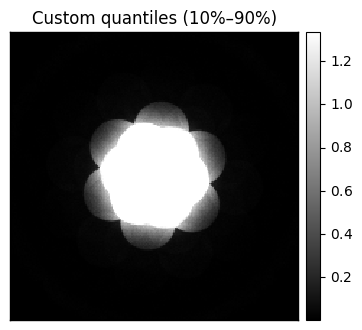

In [41]:
# Custom quantile range
show_2d(
    dp,
    norm=ShowParams.Norm(lower_quantile=0.1, upper_quantile=0.9),
    title="Custom quantiles (10%–90%)",
    cbar=True,
);

### 2c. String presets (no import needed)

You can also pass a string name directly to `norm=` for quick use.
Available presets: `"linear_auto"` / `"quantile"`, `"minmax"`, `"linear_centered"`,
`"log_auto"`, `"log_minmax"`, `"power_sqrt"`, `"power_squared"`, `"asinh_centered"`.

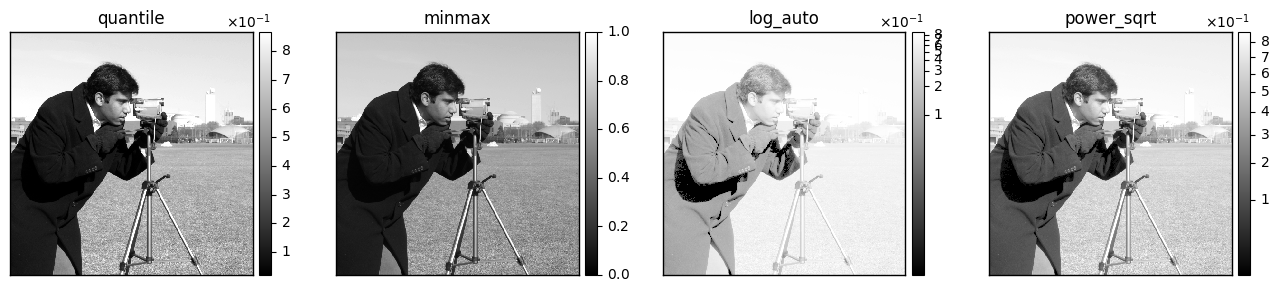

In [42]:
show_2d(
    [cameraman, cameraman, cameraman, cameraman],
    norm=["quantile", "minmax", "log_auto", "power_sqrt"],
    title=["quantile", "minmax", "log_auto", "power_sqrt"],
    cbar=True,
);

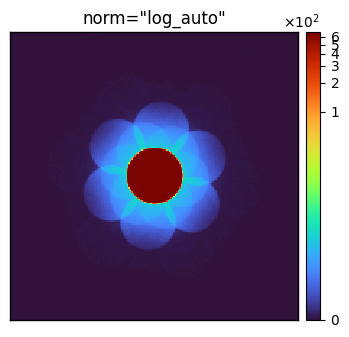

In [14]:
# Single string preset
show_2d(dp, norm="log_auto", cmap="turbo", cbar=True, title='norm="log_auto"');

## 3. Scale Bar with `ShowParams.Scalebar`

`ShowParams.Scalebar` adds a labelled scale bar. Set `sampling`
(physical units per pixel) and `units`; everything else has sensible
defaults. The label is **bold by default** and the `fontsize` can be
adjusted.

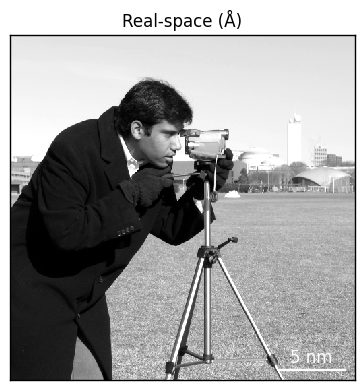

In [46]:
# Real-space scale bar (Å)
show_2d(
    cameraman,
    scalebar=ShowParams.Scalebar(sampling=0.5, units="Å"),
    title="Real-space (Å)",
);

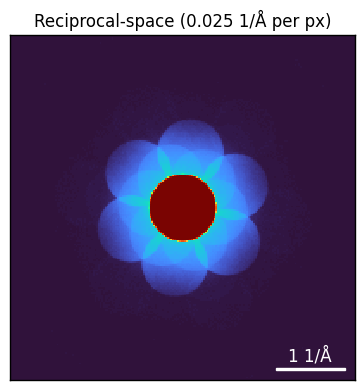

In [45]:
# Reciprocal-space scale bar using actual ducky sampling
show_2d(
    dp,
    norm=ShowParams.Norm.log_auto(),
    scalebar=ShowParams.Scalebar(sampling=recip_sampling, units="1/Å"),
    cmap="turbo",
    title=f"Reciprocal-space ({recip_sampling:.3f} 1/Å per px)",
);

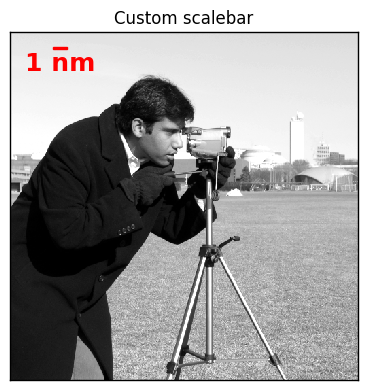

In [48]:
# Customised: colour, location, fixed length, large font
show_2d(
    cameraman,
    scalebar=ShowParams.Scalebar(
        sampling=0.5,
        units="Å",
        length=10.0,
        color="red",
        loc="upper left",
        width_px=3,
        fontsize=18,
        bold=True,
    ),
    title="Custom scalebar",
);

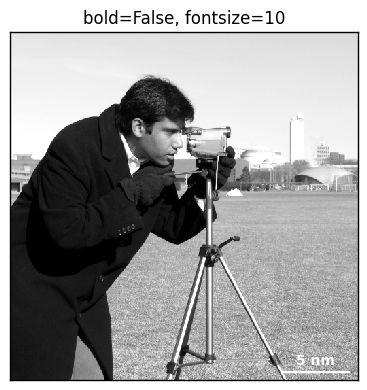

In [50]:
# Bold, smaller font
show_2d(
    cameraman,
    scalebar=ShowParams.Scalebar(sampling=0.5, units="Å", bold=True, fontsize=10),
    title="bold=False, fontsize=10",
);

## 4. Colormaps

Pass any matplotlib colormap name via `cmap=`. The package also registers
`"turbo_black"` (turbo with a fade-to-black at low values).

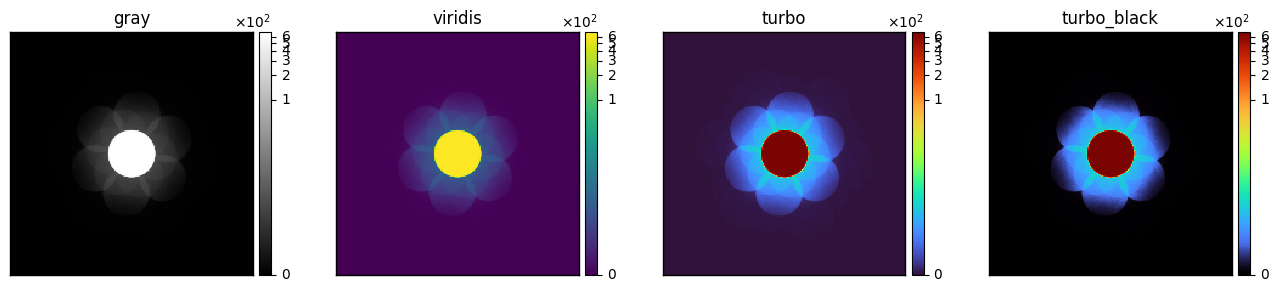

In [51]:
show_2d(
    [dp, dp, dp, dp],
    cmap=["gray", "viridis", "turbo", "turbo_black"],
    title=["gray", "viridis", "turbo", "turbo_black"],
    norm=ShowParams.Norm.log_auto(),
    cbar=True,
);

## 5. Colorbar

Set `cbar=True`. For complex data the colorbar shows both amplitude and
phase (argument).

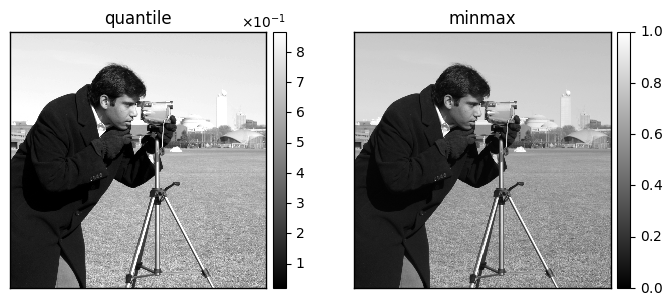

In [55]:
# Real data with colorbar
show_2d(
    [cameraman, cameraman], cbar=True, norm=["quantile", "minmax"], title=["quantile", "minmax"]
);

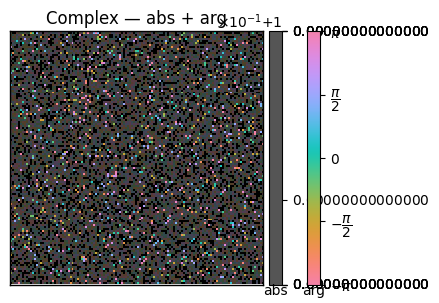

In [56]:
# Complex data — amplitude + phase colorbars
phase = np.exp(1j * np.random.uniform(-np.pi, np.pi, (128, 128)))
show_2d(phase, cbar=True, title="Complex — abs + arg");

## 6. Combined Images

`combine_images=True` maps each array to a unique hue and overlays them
into a single perceptually-uniform colour image.

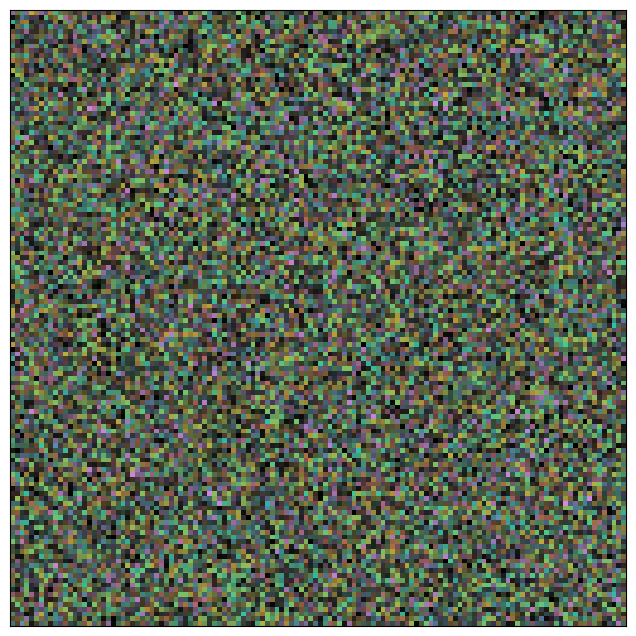

In [22]:
a = np.random.rand(128, 128)
b = np.random.rand(128, 128)
c = np.random.rand(128, 128)

show_2d([a, b, c], combine_images=True, title="3-channel overlay");

## 7. Grid Layouts with Per-Panel Settings

Display arguments (`norm`, `scalebar`, `cmap`, `cbar`, `title`) can be
single values (broadcast to all panels) or sequences matching the grid
shape.

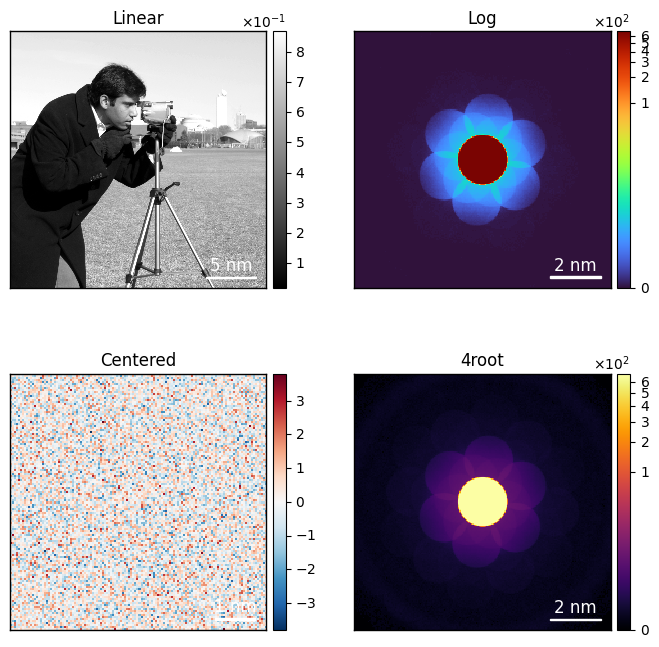

In [58]:
show_2d(
    [[cameraman, dp], [centered_data, dp]],
    norm=[
        [ShowParams.Norm(), ShowParams.Norm.log_auto()],
        [ShowParams.Norm.centered(), ShowParams.Norm(power=0.25)],
    ],
    cmap=[
        ["gray", "turbo"],
        ["RdBu_r", "inferno"],
    ],
    title=[
        ["Linear", "Log"],
        ["Centered", "4root"],
    ],
    cbar=True,
    scalebar=ShowParams.Scalebar(sampling=0.5, units="Å"),
);

## 8. Saving Figures

Use `save=` to write the figure to disk (PNG, PDF, SVG, etc.).

Saving figure to /tmp/tmpq6z7kjvj/example.png
File exists: True, size: 306177 bytes


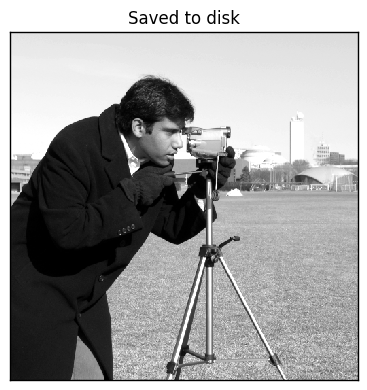

In [24]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, "example.png")
    show_2d(cameraman, save=path, title="Saved to disk")
    print(f"File exists: {os.path.exists(path)}, size: {os.path.getsize(path)} bytes")

## 9. Backward-Compatible Dict and String Forms

The old dict / string API still works — `ShowParams` is purely additive.

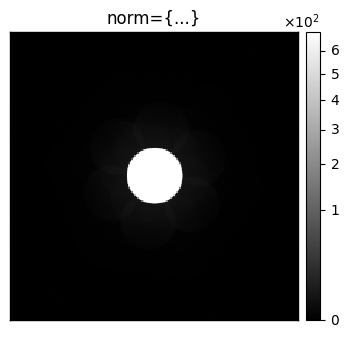

In [25]:
# Dict norm
show_2d(dp, norm={"stretch_type": "power", "power": 0.5}, cbar=True, title="norm={...}");

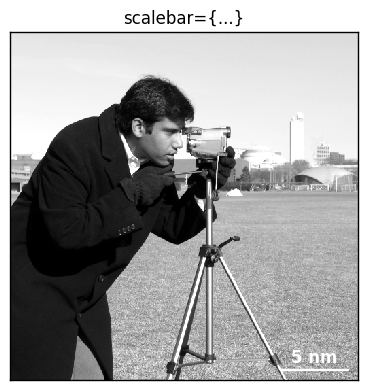

In [ ]:
# Dict scalebar
show_2d(cameraman, scalebar={"sampling": 0.5, "units": "Å"}, title="scalebar={...}");